# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código


In [3]:

# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos)
print(usage.isna().mean()) # Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Dataset plans**
✅ Tamaño: Solo 2 registros (2 planes disponibles)
Completitud: 100% - No hay valores nulos en ninguna columna
Calidad: Excelente - todos los datos están completos

**Dataset users_latam (4,000 clientes):**
✅ Columnas sin problemas:
- user_id, first_name, last_name, age, reg_date, plan: 0% nulos
- Acción: Mantener tal como están - datos completos y confiables

⚠️ Columnas con valores faltantes:
**city (11.73% nulos)**
- Diagnóstico: Problema menor, dentro del rango manejable (5-30%)
- Acción: Crear categoría "Ciudad no especificada" o imputar con "Desconocida"
- Justificación: Es información geográfica útil para segmentación, pero no crítica

**churn_date (88.35% nulos)**
- Diagnóstico: NO es un problema - son clientes activos
- Acción: Mantener como está, usar para crear variable binaria is_active
- Justificación: Los nulos representan clientes que no han cancelado (información valiosa)

 Dataset usage (40,000 registros):
✅ Columnas sin problemas:
- id, user_id, type: 0% nulos - estructura sólida

⚠️ Columnas con valores faltantes:
**date (0.125% nulos)**
- Diagnóstico: Problema mínimo (<5%)
- Acción: Eliminar los 50 registros sin fecha o imputar con fecha promedio
- Justificación: Son muy pocos registros y la fecha es crítica para análisis temporal


**duration (55.19% nulos)**
- Diagnóstico: NO es problema - son mensajes de texto
- Acción: Mantener como está, usar para identificar llamadas vs mensajes
- Justificación: Los nulos indican que el registro es un mensaje, no una llamada

**length (44.74% nulos)**
- Diagnóstico: NO es problema - son llamadas telefónicas
- Acción: Mantener como está, complementa la lógica de duration
- Justificación: Los nulos indican que el registro es una llamada, no un mensaje

**PLAN DE LIMPIEZA RECOMENDADO:**
- Crear variable is_active en users_latam basada en churn_date
- Imputar city con "Desconocida" o eliminar registros si no afecta análisis
- Eliminar 50 registros sin fecha en usage (0.125% del total)
- Crear variables is_call y is_message basadas en duration/length



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` cuenta con 4,000 ID de usuarios únicos, un promedio/media de 11,999.5 rango: min 10,000 - máx 13,999. 
- La columna `age`cuenta con 4,000 registros de edad de usuarios, rango de edad entre -999 a 79 años, edad promedio 33.73 años, y una mediana de 47 años.
- Valor anómalo detectado: edad Mínima negativa -999 (valor imposible), cuartil 25%: 32 años, cuartil 75%: 63 años. 


In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas `id` y `user_id`cuentan con la misma cantidad de resgistros únicos de 40,000.00; sin usuarios duplicados.  	
- En la columna 'duration' la media es 5.2 minutos por llamada, su mediana de 3.5 minutos, con uba distribución sesgada hacia la derecha (media>mediana), con valor de 0 en mínimo.
- En la columna 'length' (longitud de mensajes) la media es de 52 caracteres por mensaje, la mediana es de 50 caracteres, distribución relativamente simétrica, con valor de 0 en mínimo.  


In [14]:
# explorar columnas categóricas de users
columnas_users = ['city', 'plan']
users[['city', 'plan']].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` cuenta con un total de 3,531 de registros, con 7 ciudades únicas, la más frecuente es Bogotá con 808 usuarios.
- La columna `plan` cuenta con un total de registros de 4,000 usuarios, 2 tipos de planes únicos, el plan más frecuente es el Básico con 2,595 de usuarios.

In [15]:

# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene un toal de 40,000 registros de uso, solo 2 tipos únicos de uso, el tipo más frecuente es "text" con 22,092. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
  
  **Valores inválidos o sentinels identificados:**
1. **Columna age - CRÍTICO:**
- Sentinel detectado: -999 (edad mínima imposible)
- Problema: Una edad negativa es físicamente imposible
- Acción recomendada: Reemplazar -999 por NaN usando df['age'].replace(-999, pd.NA)

2. **Columna duration - SOSPECHOSO:**
- Valor cuestionable: 0 minutos (mínimo)
- Problema: ¿Puede existir una llamada de 0 minutos?
- Acción recomendada: Investigar si 0 representa llamadas no completadas o es un sentinel. Considerar filtrar o marcar como NaN según reglas de negocio.

3. **Columna length - SOSPECHOSO:**
- Valor cuestionable: 0 caracteres (mínimo)
- Problema: ¿Puede existir un mensaje de 0 caracteres?
- Acción recomendada: Validar si representa mensajes vacíos legítimos o errores de captura.

4. **Columna city - DATOS FALTANTES:**
- Problema: 3,531 registros vs 4,000 en plan (469 valores faltantes)
- Acción recomendada: Verificar valores NaN con users['city'].isna().sum()

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce") # completa el código

# Verificar el cambio de tipo
print("Nuevo tipo de dato:", users['reg_date'].dtype)


# Ver los primeros valores convertidos
print(users['reg_date'].head())

Nuevo tipo de dato: datetime64[ns]
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce") # completa el código

# Verificar el cambio de tipo
print("Nuevo tipo de dato:", usage['date'].dtype)

# Ver los primeros valores convertidos
print(usage['date'].head())

Nuevo tipo de dato: datetime64[ns]
0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, muestra conteo por año de los registros de clientes, presenta 4 años de registros y la cantidad de clientes (2022: 1,314; 2023: 1,316; 2024: 1,330; 
y en 2026 aparecen 40 clientes), la mayoría de los datos están entre el 2022-2024. Los 40 registros del 2026 pueden ser anamolía detectada: error de captura o problema en el registro, por tanto son datos que necesitan limpieza. 

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, hay 39,950 registros del año 2024.  
Basaremos el análisis en estas fechas.

✍️
 **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
date: NO en date - Solo aparece 2024, que es el año actual y válido. Parece ser más "limpia" - solo 2024
reg_date: Aquí SÍ encontraste 40 registros problemáticos en 2026. Tiene distribución histórica (2022-2024) + datos problemáticos (2026)

- ¿Qué harías con ellas?
Los datos de uso/date son más recientes y controlados automáticamente, se quedarían igual  
Los registros de clientes pueden tener errores de captura históricos, la recomendación para los 40 registros de 2026 sería:
Eliminar: Son solo 40 de ~40,000 registros (0.1%), Ventaja: Datos limpios inmediatamente, Riesgo: Perder información de clientes reales. O Marcar como problemáticos, Ventaja: Mantener trazabilidad y Uso: Análisis separado de datos dudosos.

---
## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age" ].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace("?", pd.NA)

# Verificar que funcionó:
print(users['city'].value_counts(dropna=False))

# Verificar cambios
users['city'].describe()

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
mask = users['reg_date'].dt.year == 2026
users.loc[mask, 'reg_date'] = pd.NaT

# Reconvertir explícitamente a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verificar el tipo
print("Tipo final:", users['reg_date'].dtype)
print("Valores nulos:", users['reg_date'].isna().sum())

# Verificar cambios
users['reg_date'].describe()

Tipo final: datetime64[ns]
Valores nulos: 40


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
proporcion_nulos_por_tipo = usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())
print(proporcion_nulos_por_tipo.sort_values(ascending=False))

# Contar nulos y no nulos por tipo
tabla_contingencia = pd.crosstab(usage['type'], usage['duration'].isna(), margins=True)
print(tabla_contingencia)

# Investiga esos 16 casos raros
textos_con_duracion = usage[(usage['type'] == 'text') & (usage['duration'].notna())]
print(textos_con_duracion[['type', 'duration', 'length']].head())

type
text    0.999276
call    0.000000
Name: duration, dtype: float64
duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000
       type  duration  length
1414   text     120.0    65.0
1824   text     120.0    40.0
1932   text     120.0    69.0
2972   text     120.0    68.0
11456  text     120.0    23.0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` 
Los nulos en duration NO son Missing At Random - son sistemáticos y lógicos basados en el tipo de comunicación.
Decisión: ✅ Mantener los nulos porque representan la realidad del negocio tanto para mensajes de texto como para llamadas. 
text (mensajes): 99.93% tienen valores faltantes en duration.
call (llamadas): 0% tienen valores faltantes en duration.
Interpretación: Casi todos los mensajes de texto no tienen duración registrada; se miden por longuitud de carácteres (lo cual es lógico/los 16 casos raros podrían ser outliers o con algún contenido de audio), mientras que todas las llamadas sí tienen duración.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [24]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
         .agg({"is_text": "sum",
               "is_call": "sum",
               "duration": "sum"
              })
         .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [25]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'duration': 'cant_minutos_llamada',
    'is_call': 'cant_llamadas',
    'is_text': 'cant_mensajes'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [27]:
# Resumen estadístico de las columnas numéricas
user_profile[user_profile['reg_date'].dt.year == 2024].describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000
mean,13332.699248,48.414286,5.500000,4.557143,24.126669
std,384.969999,17.963443,2.382293,2.140329,19.458620
min,12666.000000,18.000000,0.000000,0.000000,0.000000
25%,12999.250000,33.000000,4.000000,3.000000,11.332500
50%,13333.500000,48.000000,5.000000,4.000000,20.325000
75%,13665.750000,64.000000,7.000000,6.000000,32.542500
max,13999.000000,79.000000,16.000000,13.000000,155.690000


In [28]:
# Distribución porcentual del tipo de plan con .describe
print(user_profile['plan'].describe()
     )

#Distribución porcentual con value_counts
print(user_profile['plan'].value_counts(normalize=True) * 100)

count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

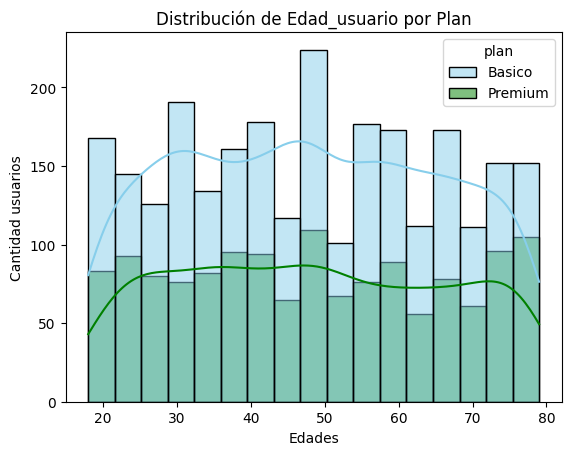

In [51]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)

# Títulos y etiquetas
plt.title('Distribución de Edad_usuario por Plan')
plt.xlabel('Edades')
plt.ylabel('Cantidad usuarios')
plt.show()


💡Insights: 
- Distribución mayoritaria como pico principal está alredor de los 48 años. La edad mínima es de 18 años.
- El Plan Básico (azul) domina en casi en todos los grupos de edad.
- Plan premium (verde) presenta menor representación, pero presenten en todas las edades.
- Patrones por edad:
20-30 años: Mayoría usa plan Básico
40-50 años: Mayor concentración de usuarios (ambos planes), predominando plan Básico
60+ años: Sigue predominando el plan Básico

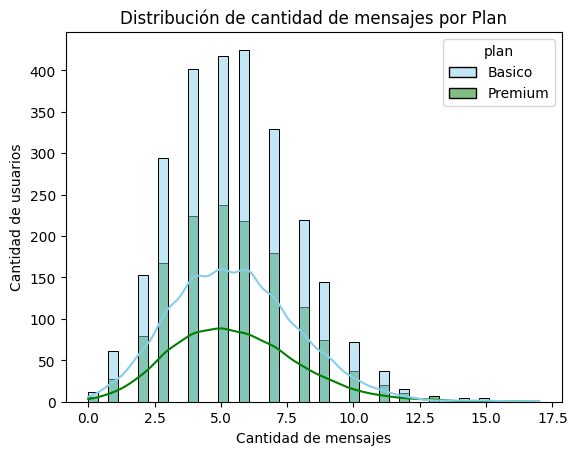

In [50]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)

# Títulos y etiquetas
plt.title('Distribución de cantidad de mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()



💡Insights: 
- "Los usuarios de plan Básico tienden a hacer más envios de mensajes un promedio de 5-6, que los de plan Premium."
- Hay una distribución asimétrica hacia la derecha con envios de hasta 16 mensajes como máximo. 

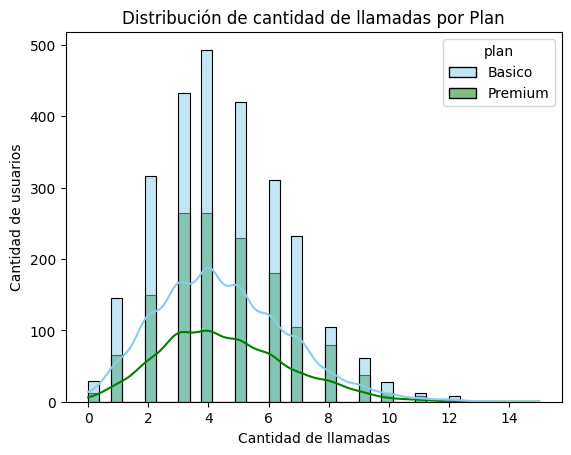

In [49]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)

# Títulos y etiquetas
plt.title('Distribución de cantidad de llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Distribución del Plan Básico (azul): Se concentra principalmente en el rango de 3-5 llamadas. Plan Premium (verde): Tiene una distribución más amplia, con usuarios que llegan hasta 10+ llamadas
- La mayoría de usuarios (ambos planes) están en el promedio de 4 llamadas.
- Hay una "cola larga" hacia la derecha con usuarios de alto uso con un máximo de 13 llamadas.

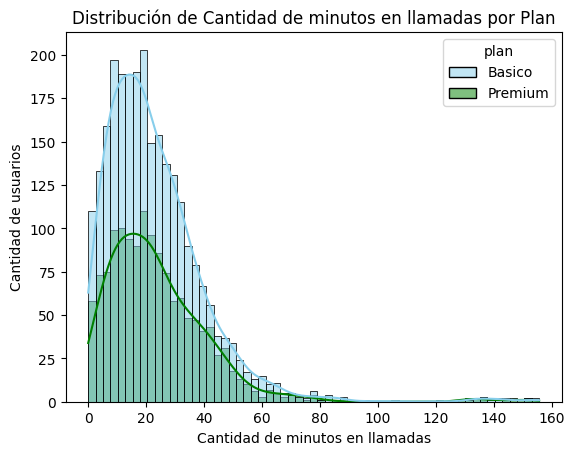

In [48]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)


# Títulos y etiquetas

plt.title('Distribución de Cantidad de minutos en llamadas por Plan')
plt.xlabel('Cantidad de minutos en llamadas')
plt.ylabel('Cantidad de usuarios')

plt.show()



💡Insights: 

**Usuarios de plan Básico:**
- Hacen pocas llamadas (2-6) Y hablan pocos minutos (0-20)
**Usuarios Premium:**
- Hacen más llamadas (hasta 10+) Y hablan más minutos(hasta 150+)
- La distribución: es asimétrica, tiene cola larga a la derecha con llamadas de hasta 155 minutos, aunque se presentan valores concentrados en ciertos rangos 0-20.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  

- Crea un **for** para generar los 4 boxplots automáticamente.
<br>


- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

Analizando:age


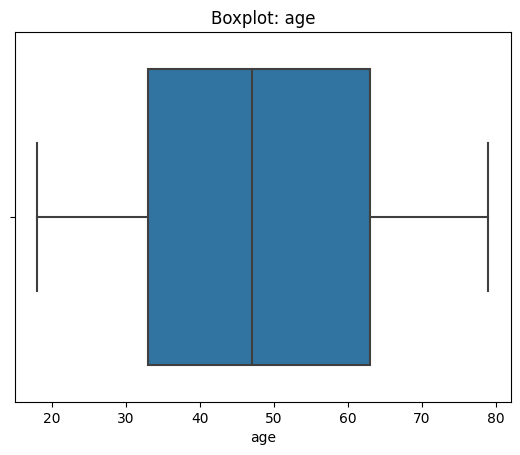

Analizando:cant_mensajes


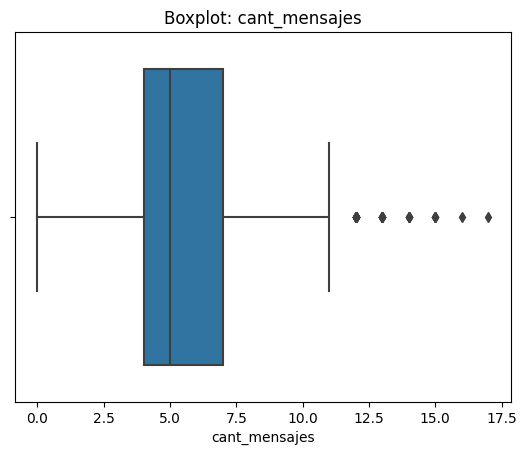

Analizando:cant_llamadas


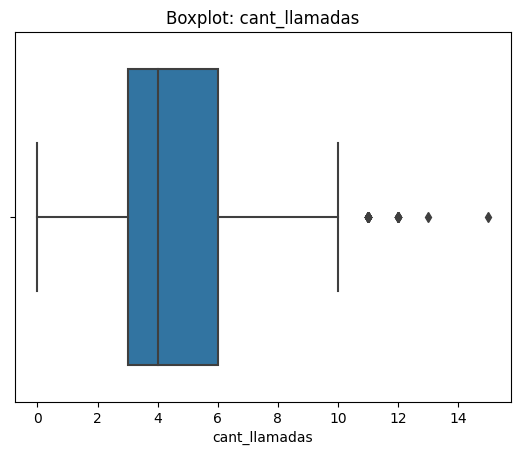

Analizando:cant_minutos_llamada


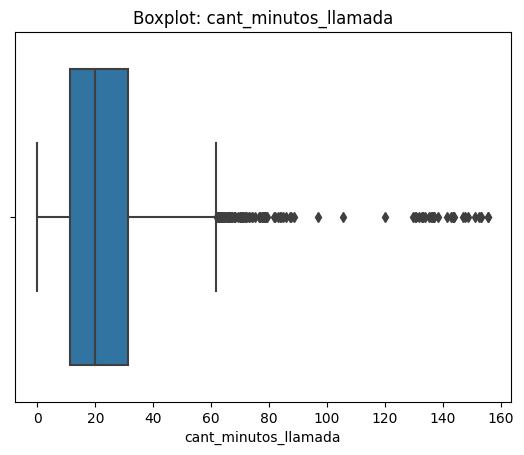

In [59]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


# Crea un **for** para generar los 4 boxplots automáticamente
for col in columnas_numericas:
    print(f"Analizando:{col}")
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    
# Muestra el gráfico
    plt.show()


💡Insights: 
- Age: no presenta outliers
- cant_mensajes: sí presenta outliers
- cant_llamadas: sí presenta outliers
- cant_minutos_llamada: sí presenta outliers

Analizando:cant_mensajes
Primer cuartil:  4.0
Tercer cuartil:  7.0
IQR:  3.0
Límite superior:  11.5


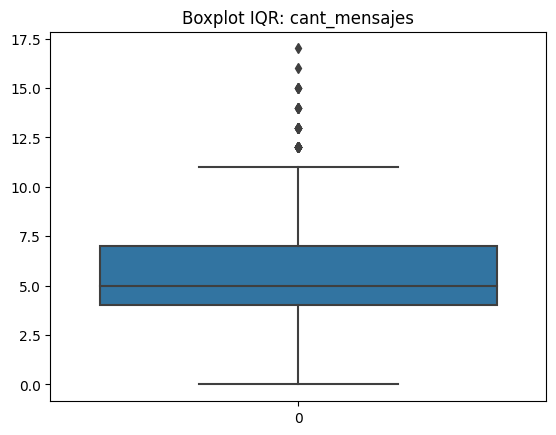

Analizando:cant_llamadas
Primer cuartil:  3.0
Tercer cuartil:  6.0
IQR:  3.0
Límite superior:  10.5


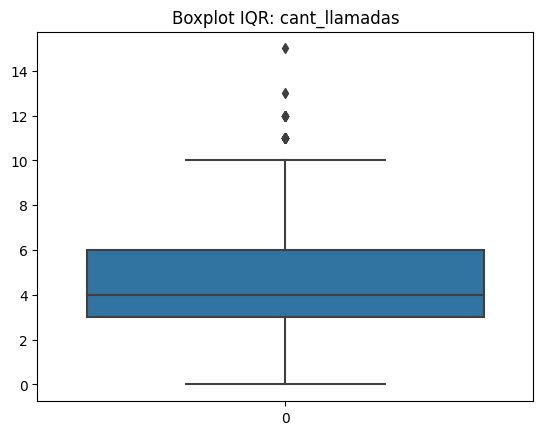

Analizando:cant_minutos_llamada
Primer cuartil:  11.12
Tercer cuartil:  31.415
IQR:  20.295
Límite superior:  61.8575


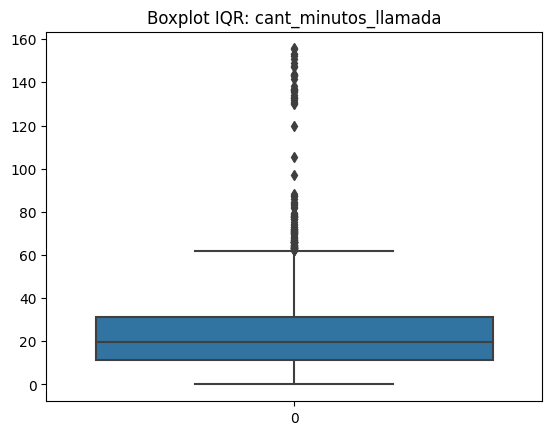

In [71]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Crea un bucle para calcular el IQR automáticamente
for col in columnas_limites:
    print(f"Analizando:{col}")
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil: ', Q1)
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil: ', Q3)
    IQR = Q3 - Q1
    print('IQR: ', IQR)
    upper = Q3 + 1.5 * IQR
    print('Límite superior: ', upper)

    sns.boxplot(data=user_profile[col])
    plt.title(f'Boxplot IQR: {col}')
    plt.show()
# Muestra el gráfico


In [70]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? MANTENER para dar respuesta al objetivo y necesidad de ConnectaTel sobre tener segmentos diferenciados y optimizar su oferta comercial dirigida, conocer e identificar estos usuarios para ofertarles de forma directa algún plan con beneficios a su uso de SMS ilimitados.
- cant_llamadas: mantener o no outliers, porqué?  MANTENER los clientes que hacen más de 10 llamadas son clientes de alto voalor para el negocio, pueden estar necesitando algún plan empresarial/premium o reconocimiento de +leltad para mantenerlos y obtener mayor ganancia. 
- cant_minutos_llamada: mantener o no outliers, porqué? MANTENER para analizarlos de forma separada, permitiendo identificar si es un comportamiento atípico, o bien de qué segmento es el cliente,si es de uso empresarial, para ofertarle un plan más acorde, o alguna promoción  para mantener conversaciones de más 60 minutos/ o descartar que no se colgó correctamente, fallo del sistema, etc. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [89]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = None

# Función para clasificar clientes
def grupo_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
   
# Segmentación Bajo uso
    if llamadas >= 10 or mensajes >= 10:
        return "Alto uso"
    elif llamadas >= 5 or mensajes >= 5:
        return "Uso Medio"
    else:
        return "Bajo uso"

# aplicar función y ver cambios
user_profile["grupo_uso"] = user_profile.apply(grupo_uso, axis=1)
user_profile[["grupo_uso", "cant_llamadas", "cant_mensajes"]].head()


,grupo_uso,cant_llamadas,cant_mensajes
0,Uso Medio,3.0,7.0
1,Alto uso,10.0,5.0
2,Uso Medio,2.0,5.0
3,Alto uso,3.0,11.0
4,Bajo uso,3.0,4.0


In [91]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso Medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [94]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = None

# Función para clasificar clientes
def grupo_edad(row):
    edad = row['age']
   
# Segmentación Joven
    if edad < 30:
        return "Joven"
    elif edad < 60: 
        return "Adulto"
    else:
        return "Adulto mayor"

# aplicar función y ver cambios
user_profile["grupo_edad"] = user_profile.apply(grupo_edad, axis=1)
user_profile[["grupo_edad", "age"]].head()


,grupo_edad,age
0,Adulto,38.0
1,Adulto,53.0
2,Adulto,57.0
3,Adulto mayor,69.0
4,Adulto mayor,63.0


In [99]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

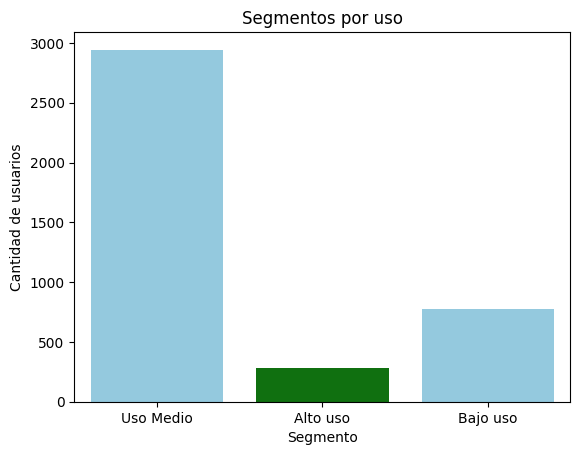

In [108]:

# Visualización de los segmentos por uso
user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)

# Crea el gráfico
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue','green'])

plt.title('Segmentos por uso')
plt.ylabel('Cantidad de usuarios')
plt.xlabel('Segmento')

# Muestra el gráfico
plt.show()



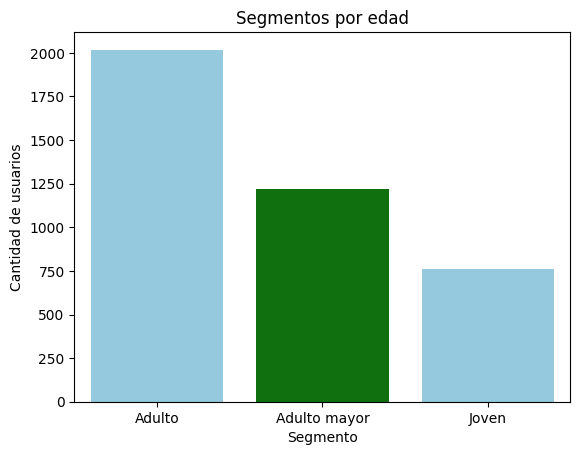

In [109]:
# Visualización de los segmentos por edad

user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)

# Crea el gráfico
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green'])

plt.title('Segmentos por edad')
plt.ylabel('Cantidad de usuarios')
plt.xlabel('Segmento')

# Muestra el gráfico
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


**Problemas originales en los datos**
Durante el proceso de limpieza se detectaron los siguientes issues relevantes:
Columna city: 469 valores nulos de 4,000 usuarios → 11.7% de registros incompletos.
Impacto: limita análisis geográfico y segmentación regional.
Columna churn_date: 466 registros con fecha de cancelación → 11.65% tasa de churn histórica. No es error, pero requiere tratamiento adecuado para análisis de retención.
Tabla de uso (40,000 registros)
Variables clave:
duration (llamadas): 22,076 valores nulos → 55% sin duración registrada/Riesgo de subestimar consumo real
length (mensajes): 17,896 valores nulos → 44.7% sin longitud registrada/Riesgo de subestimar consumo real
date: 50 valores nulos → 0.1% impacto mínimo
📌 Insight clave: Los datos eran sólidos, pero requerían tratamiento estratégico de nulos para evitar sesgos en el análisis de consumo y dar atención a las necesidades de información del cliente.

**Segmentos de clientes / + valiosos**
Segmento Adulto: 40–50 años, representa el mayor volumen de clientes, es el grupo con mayor actividad combinada y mayor probabilidad de excedentes (minutos/llamadas). Este grupo es el principal generador de ingresos actuales y futuros.
Segmento Joven 20–30 años, menor volumen relativo, con uso más variable, posiblemente con mayor sensibilidad al precio. Potencial de churn más alto, segmento de crecimiento, pero no el objetivo financiero actual.
 Segmento Adulto mayor, Heavy Users dentro del Plan Básico, tiene una distribución asimétrica con cola larga, supera ampliamente el promedio de uso hatas 2-3 veces el promedio mensual. Paga excedentes, puede estar en riesgo de churn por sobrecosto, o bien, puedes er el mayor potencial de expansión de ingresos para el negocio.
📌 Insight clave: La estructura actual de planes es binaria: Básico (dominante), Premium (minoría), pero el comportamiento real es TRINARIO: Bajo uso, Uso medio y Uso intensivo (subsegmento oculto). El producto ofertado no refleja el comportamiento real del cliente.

**Patrones outliers**
Se identificaron: Usuarios con consumo muy superior al promedio. Distribución sesgada positivamente (cola larga).
Implicaciones de negocio: Indican que el plan básico podría ser insuficiente para un subgrupo.
Existe potencial pérdida de margen si el precio del Premium no está a corde a las necesidades del cliente. Riesgo de churn en adultos mayores si perciben penalización constante por excedentes a su plan "Básico".
📌 Insight clave: Los outliers no son ruido — son oportunidades de diseño de plan intermedio o especializado.

**Recomendaciones**
1. Crear Plan Intermedio (Oportunidad inmediata) para un target de 35-55 años
2. Sistema Predictivo para detectar clientes que exceden límites 2 meses consecutivos y realizar oferta automática personalizada.
📌 Insight clave: ConnectaTel no necesita crecer en clientes. Necesita crecer en inteligencia comercial. La rentabilidad futura está en capturar mejor el valor del cliente que ya confía en la marca.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`